In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")



In [2]:
BASE_PATH = Path("/kaggle/input/tabular-playground-series-dec-2021")

train_path = BASE_PATH / "train.csv"
test_path = BASE_PATH / "test.csv"
sample_sub_path = BASE_PATH / "sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_sub_path)



In [3]:
TARGET_COL = "Cover_Type"
ID_COL = "Id"

X = train_df.drop(columns=[TARGET_COL, ID_COL])
y = train_df[TARGET_COL]

# Simple train/validation split without stratify (some classes have only one sample)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)



In [4]:
model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=None,
    random_state=42,
)

model.fit(X_train, y_train)



HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200,
                               random_state=42)

In [5]:
val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print(f"Validation accuracy: {val_acc:.5f}")



Validation accuracy: 0.94105


In [6]:
X_test = test_df.drop(columns=[ID_COL])
test_pred = model.predict(X_test)

submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: test_pred.astype(int)})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head()



Saved submission.csv


,Id,Cover_Type
0,814683,1
1,1357371,2
2,2106112,1
3,3483684,1
4,3960754,1


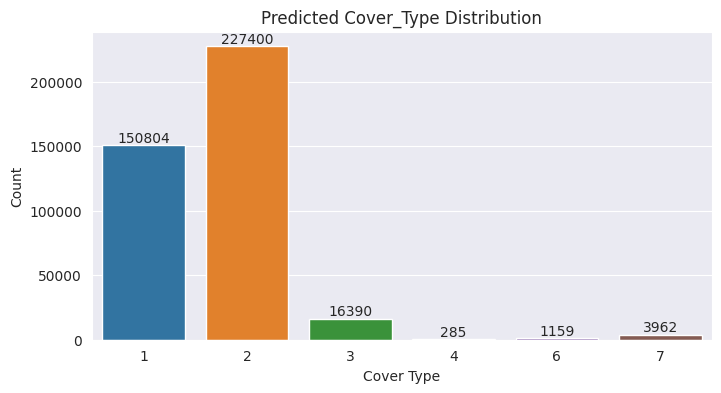

In [7]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x=TARGET_COL, data=submission)
plt.title("Predicted Cover_Type Distribution")
plt.xlabel("Cover Type")
plt.ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()